#Import Libraries


In [1]:
#Basic libraries
import numpy as np
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Statistical modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

###Observation:-
The required libraries for data manipulation (Numpy, Pandas), visualization (Matplotlib, Seaborn), statistical modeling (Statsmodels, Scipy), and model evaluation (Scikit-learn) have been successfully imported. These libraries will be used for performing EDA, building the linear regression model, testing assumptions, and evaluating model performance.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ottdata.csv')

Mounted at /content/drive


###Observation:-
The Google Drive has been successfully mounted, and the dataset (ottdata.csv) has been loaded into the dataframe df.

#Exploratory Data Analysis
##Checking the Structure of Data

In [3]:
print(df.head())

   visitors  ad_impressions  major_sports_event     genre  dayofweek  season  \
0      1.67         1113.81                   0    Horror  Wednesday  Spring   
1      1.46         1498.41                   1  Thriller     Friday    Fall   
2      1.47         1079.19                   1  Thriller  Wednesday    Fall   
3      1.85         1342.77                   1    Sci-Fi     Friday    Fall   
4      1.46         1498.41                   0    Sci-Fi     Sunday  Winter   

   views_trailer  views_content  
0          56.70           0.51  
1          52.69           0.32  
2          48.74           0.39  
3          49.81           0.44  
4          55.83           0.46  


###Observation:-
The first five records indicate that the dataset includes a balanced mix of numerical and categorical variables influencing first-day content performance. Marketing metrics (**ad_impressions**, **views_trailer**), platform traffic (**visitors**), and release characteristics (**genre**, **dayofweek**, **season**) vary across observations, suggesting potential drivers of variability in **views_content**. The structure appears clean and consistent for further analysis.




In [4]:
print(df.tail())

     visitors  ad_impressions  major_sports_event    genre  dayofweek  season  \
995      1.58         1311.96                   0  Romance     Friday    Fall   
996      1.34         1329.48                   0   Action     Friday  Summer   
997      1.62         1359.80                   1   Sci-Fi  Wednesday    Fall   
998      2.06         1698.35                   0  Romance     Monday  Summer   
999      1.36         1140.23                   0   Comedy   Saturday  Summer   

     views_trailer  views_content  
995          48.58           0.36  
996          72.42           0.56  
997         150.44           0.66  
998          48.72           0.47  
999          52.94           0.49  


###Observation:-
The dataset contains 1000 observations, indicating a reasonably sized dataset for building a regression model.
The structure appears consistent across the dataset, with no visible formatting issues in the last few rows.

In [5]:
print(df.shape)

(1000, 8)


###Observation:-
The dataset contains 1000 rows and 8 columns, indicating 1000 content release observations with 7 predictor variables and 1 target variable (**views_content**)

In [6]:
print(df.columns)

Index(['visitors', 'ad_impressions', 'major_sports_event', 'genre',
       'dayofweek', 'season', 'views_trailer', 'views_content'],
      dtype='object')


###Observation:-
The dataset contains the following variables:


*   **visitors**

*   **ad_impressions**

*   **major_sports_event**

*   **genre**
*   **dayofweek**


*   **season**


*   **views_trailer**


*   **views_content** (Target Variable)

Among these:


*   **views_content** will be treated as the dependent variable.

*   **visitors**, **ad_impressions**, and **views_trailer** are numerical predictors.
*   **major_sports_event** is a binary variable.


*   **genre**, **dayofweek**, and **season** are categorical variables.







In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB
None


###Observation:-
The dataset contains 1000 observations with no missing values across any of the 8 variables, indicating a complete dataset ready for analysis.


*   Four variables (**visitors**, **ad_impressions**, **views_content**) are continuous numerical variables.

*   **major_sports_event** is an integer variable representing a binary indicator (0/1).
*   Three variables (**genre**, **dayofweek**, **season**) are categorical in nature.

Since there are no null values and the data types are appropriately assigned, no immediate data cleaning is required.






In [8]:
print(df.isnull().sum())

visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64


###Observation:-
There are no missing values in any of the variables. All 1000 observations contain complete data across numerical, categorical, and binary variables.

Since the dataset is fully populated, no imputation or missing value treatment is required before proceeding with analysis and model building.

##Checking Data Types of Columns

In [9]:
print(df.dtypes)

visitors              float64
ad_impressions        float64
major_sports_event      int64
genre                  object
dayofweek              object
season                 object
views_trailer         float64
views_content         float64
dtype: object


###Observation:-
The dataset contains:


*   4 continuous numerical variables: **visitors**, **ad_impressions**, **views_trailer**, and **views_content**

*   1 binary variable: **major_sports_event** (stored as integer type)
*   3 categorical variables: **genre**, **dayofweek**, and **season**

The data types are appropriate for their respective variables.






##Check statistical summary

In [10]:
print(df.describe())

          visitors  ad_impressions  major_sports_event  views_trailer  \
count  1000.000000     1000.000000         1000.000000     1000.00000   
mean      1.704290     1434.712290            0.400000       66.91559   
std       0.231973      289.534834            0.490143       35.00108   
min       1.250000     1010.870000            0.000000       30.08000   
25%       1.550000     1210.330000            0.000000       50.94750   
50%       1.700000     1383.580000            0.000000       53.96000   
75%       1.830000     1623.670000            1.000000       57.75500   
max       2.340000     2424.200000            1.000000      199.92000   

       views_content  
count    1000.000000  
mean        0.473400  
std         0.105914  
min         0.220000  
25%         0.400000  
50%         0.450000  
75%         0.520000  
max         0.890000  


###Observation:-
The summary statistics provide the following key insights:


*   The average first day content viewership (**views_content**) is 0.473 million, with a standard deviation of 0.106 million, indicating moderate variability in performance across releases.

*   The minimum and maximum first day views range from 0.22 million to 0.89 million, suggesting significant differences in content success.

*   The platform receives an average of 1.70 million weekly visitors, indicating relatively stable platform traffic.
*   Average ad impressions are 1434 million, though the wide range (1010 to 2424 million) suggests variability in marketing intensity.


*   The average trailer views are 66.9 million, with a maximum as high as 199.9 million, indicating some trailers generate exceptionally high engagement.


*   The **major_sports_event** variable has a mean of 0.40, implying that approximately 40% of releases coincide with major sports events, which may impact viewership.

Overall, the variability observed in marketing metrics and trailer views suggests potential strong predictors for first-day content performance.



##Check for and treat(if needed) data irregularities

In [11]:
#Checking for duplicate records
print(df.duplicated().sum())

0


###Observation:-
There are no duplicate records in the dataset. Each observation represents a unique content release, ensuring data integrity and eliminating the need for duplicate removal before analysis.

In [12]:
#Checking for logical inconsistency

#Binary Variable Check
print(df['major_sports_event'].unique())

#Content Views vs Trailer Views Logic
print((df['views_content'] > df['views_trailer']).sum())

#Category Validity Check
print(df['genre'].unique())
print(df['dayofweek'].unique())
print(df['season'].unique())

[0 1]
0
['Horror' 'Thriller' 'Sci-Fi' 'Others' 'Drama' 'Action' 'Comedy' 'Romance']
['Wednesday' 'Friday' 'Sunday' 'Thursday' 'Monday' 'Saturday' 'Tuesday']
['Spring' 'Fall' 'Winter' 'Summer']


###Observation:-
The binary variable **major_sports_event** contains only valid values (0 and 1), confirming correct encoding.

No instances were found where first day content views exceed trailer views, indicating logical consistency between promotional engagement and actual content performance.

The categorical variables (**genre**, **dayofweek**, and **season**) contain consistent and meaningful category labels with no spelling errors or unexpected  entries.

Therefore, no logical inconsistencies were identified in the dataset.

In [13]:
##Checking for invalid or unrealistic values

##Negative Value Check
print((df[['visitors', 'ad_impressions', 'views_trailer', 'views_content']] < 0).sum())

#Extreme Range Verification
print(df[['visitors', 'ad_impressions', 'views_trailer', 'views_content']].describe())

visitors          0
ad_impressions    0
views_trailer     0
views_content     0
dtype: int64
          visitors  ad_impressions  views_trailer  views_content
count  1000.000000     1000.000000     1000.00000    1000.000000
mean      1.704290     1434.712290       66.91559       0.473400
std       0.231973      289.534834       35.00108       0.105914
min       1.250000     1010.870000       30.08000       0.220000
25%       1.550000     1210.330000       50.94750       0.400000
50%       1.700000     1383.580000       53.96000       0.450000
75%       1.830000     1623.670000       57.75500       0.520000
max       2.340000     2424.200000      199.92000       0.890000


###Observation:-
All numerical variables (**visitors**, **ad_impressions**, **views_trailer**, and **views_content**) contain non-negative values, confirming the absence of impossible entries.

The ranges of the variables appear realistic and consistent:


*   Visitors range from 1.25 to 2.34 million, indicating stable platform traffic.

*   Ad impressions range from 1010 to 2424 million, reflecting variability in marketing intensity.
*   Trailer views range from 30.08 to 199.92 million, suggesting some trailers generate significantly higher engagement.


*   First day content views range from 0.22 to 0.89 million, indicating variation in content performance.

No extreme or unrealistic values were observed that violate expected business scale or logical boundaries.



In [14]:
#Checking consistency of Categorical Data

#Check for Extra Spaces
print(df['genre'].str.strip().unique())

#Check Case Consistency
for col in ['genre', 'dayofweek', 'season']:
  print(col, df[col].str.lower().unique())

#Check Category Counts
print(df['genre'].value_counts())
print(df['dayofweek'].value_counts())
print(df['season'].value_counts())

['Horror' 'Thriller' 'Sci-Fi' 'Others' 'Drama' 'Action' 'Comedy' 'Romance']
genre ['horror' 'thriller' 'sci-fi' 'others' 'drama' 'action' 'comedy' 'romance']
dayofweek ['wednesday' 'friday' 'sunday' 'thursday' 'monday' 'saturday' 'tuesday']
season ['spring' 'fall' 'winter' 'summer']
genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64
dayofweek
Friday       369
Wednesday    332
Thursday      97
Saturday      88
Sunday        67
Monday        24
Tuesday       23
Name: count, dtype: int64
season
Winter    257
Fall      252
Spring    247
Summer    244
Name: count, dtype: int64


###Observation:-
The categorical variables (**genre**, **dayofweek**, and **season**) were examined for consistency in spelling, casing and formatting.


*   All genre categories are consistently labeled with no duplicate forms.

*   Days of the week are properly formatted and limited to valid weekday names.
*   Seasons include only the four expected categories: Spring, Summer, Fall, and Winter.

The value counts indicate a reasonable distribution across categories. Notably:


*   "Others" is the most frequent genre (255 observations).

*   Friday and Wednesday have the highest number of content releases.
*   Seasonal distribution is fairly balanced across all four seasons.

Overall, no inconsistencies or formatting issues were identified in the categorical variables.










##Univariate Analysis
###Identifying NUmerical & Categorical Variables

In [15]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

Numerical Variables:
Index(['visitors', 'ad_impressions', 'major_sports_event', 'views_trailer',
       'views_content'],
      dtype='object')

Categorical Variables:
Index(['genre', 'dayofweek', 'season'], dtype='object')


###Observation:-
The dataset consists of five numerical variables and three categorical variables.

The numerical variables include platform metrics (**visitors**), marketing effort (**ad_impressions**), promotional engagement (**views_trailer**), the binary indicator (**major_sports_event**), and the target variable (**views_content**).

The categorical variables (**genre**, **dayofweek**, and **season**) represent content characteristics and release timing factors. These variables will require encoding before model building.

This classification helps structure the subsequent univariate and bivariate analysis appropriately.

###For Numerical Variables

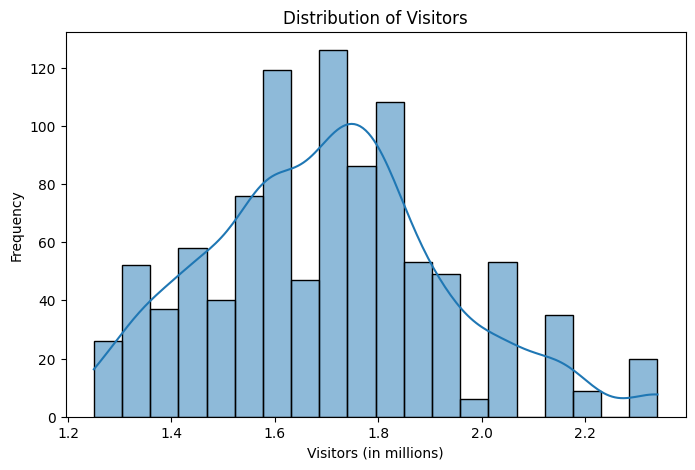

Skewness: 0.370597770139047


In [16]:
#Distribution plot for Visitors
plt.figure(figsize = (8,5))
sns.histplot(df["visitors"], kde = True)
plt.title("Distribution of Visitors")
plt.xlabel("Visitors (in millions)")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df["visitors"].skew())

###Observation:-
The distribution of **visitors** appears approximately symmetric with a slight right skew. The skewness value 0.37 indicates mild positive skewness, meaning a few observations have relatively higher platform traffic compared to the majority.

Most values are concentrated between 1.5 and 1.9 million visitors, suggesting stable weekly platform traffic with limited extreme fluctuations.

Overall, the variable does not exhibit strong skewness and appears suitable for regreesion modeling without transformation.

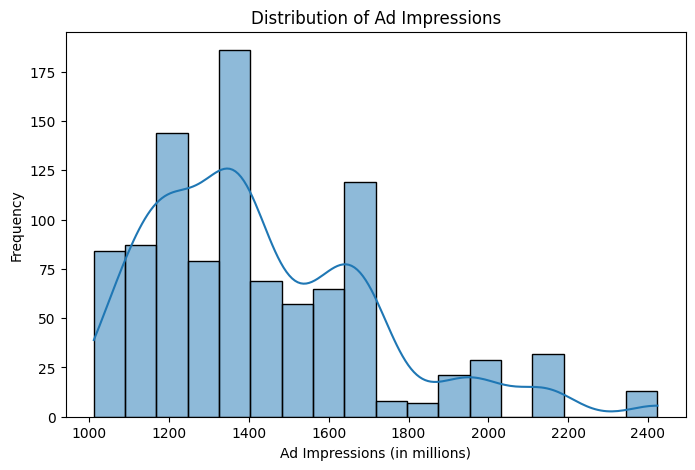

Skewness: 1.0335622338187542


In [17]:
#Distribution plot for Ad Impressions
plt.figure(figsize = (8,5))
sns.histplot(df["ad_impressions"], kde = True)
plt.title("Distribution of Ad Impressions")
plt.xlabel("Ad Impressions (in millions)")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df["ad_impressions"].skew())

###Observation:-
The distribution of **ad_impressions** is positively skewed, with a skewness value of 1.03, indicating moderate to high right skewness.

Most ad impression values are concentrated between 1100 and 1700 million, while a few campaigns exhibit substantially higher impressions (above 2000 million), creating a long right tail.

This suggests variability in marketing intensity, where certain content releases receive significantly higher promotional support compared to others.

Given the moderate skewness, this variable may slightly influence regression estimates due to extreme high values, but transformation may not be immediately necessary unless modeling assumptions are violated.

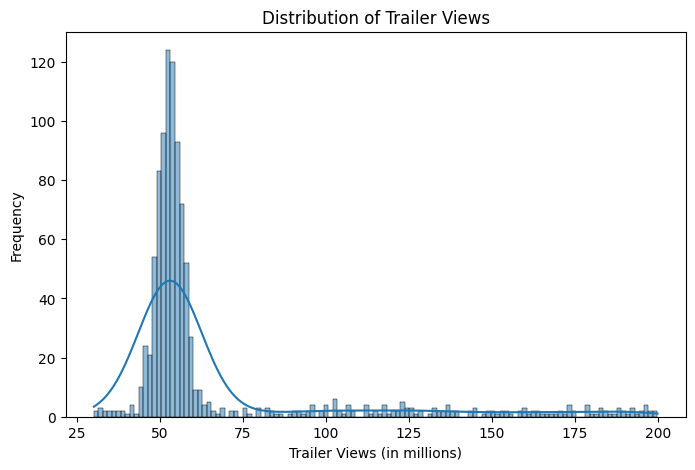

Skewness: 2.37291116913243


In [18]:
#Distribution plot for Trailer Views
plt.figure(figsize = (8,5))
sns.histplot(df['views_trailer'], kde = True)
plt.title('Distribution of Trailer Views')
plt.xlabel('Trailer Views (in millions)')
plt.ylabel('Frequency')
plt.show()

print('Skewness:', df['views_trailer'].skew())

###Observation:-
The distribution of **views_trailer** is highly positively skewed, with a skewness value of 2.37, indicting significant right skewness.

Most trailer views are concentrated between 45 and 65 million, while a small number of trailers receive exceptionally high views (above 100 million and extending close to 200 million), resulting in a long right tail.

This suggests that while most content receives moderate promotional engagement, a few trailers generate block-level attention. These extreme values may influence regression results and could potentially require transformation if model assumptions are violated.

Overall, trailer views exhibit substantial variability compared to other numerical variables.

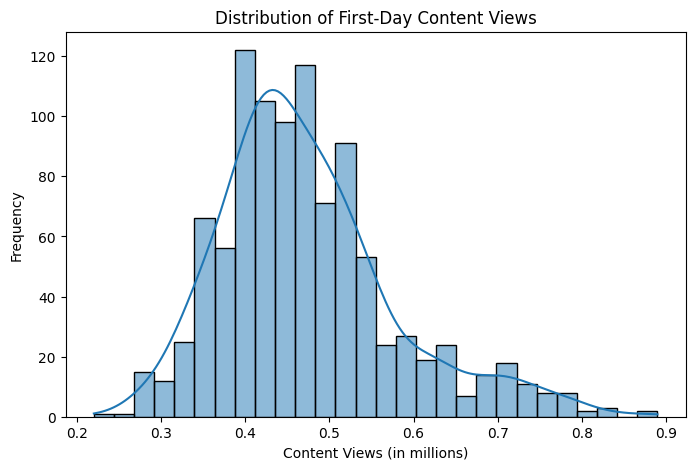

Skewness: 0.9428471566302183


In [19]:
#Distribution plot for Content Views(Target Variable)
plt.figure(figsize=(8,5))
sns.histplot(df['views_content'], kde = True)
plt.title('Distribution of First-Day Content Views')
plt.xlabel('Content Views (in millions)')
plt.ylabel('Frequency')
plt.show()

print('Skewness:', df['views_content'].skew())

###Observation:-
The distribution of **views_content** is moderately positively skewed, with a skewness value of 0.94, indicating a noticeable right skew.

Most content releases generate first-day views between 0.35 and 0.55 million, suggesting a consistent performance range for the majority of releases. However, a smaller number of titles achieve significantly higher viewership (above 0.7 million), creating a right tail in the distribution.

This pattern indicates that whle most content performs moderately, a few releases achieve exceptionally high engagement. The moderate skewness suggests that the variable is reasonably suitable for regression modeling, thought model residuals should later be examined to confirm normality assumptions.

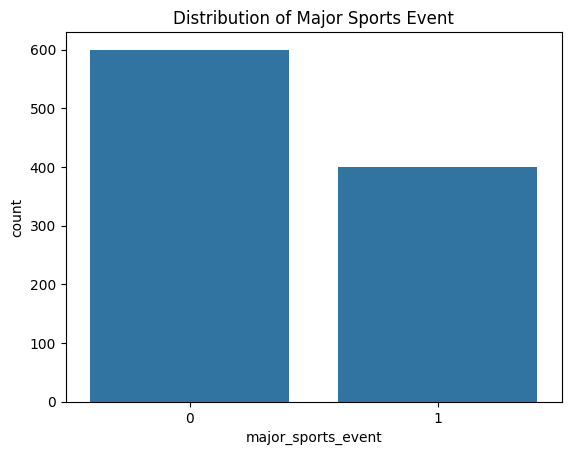

major_sports_event
0    0.6
1    0.4
Name: proportion, dtype: float64


In [20]:
#Distribution plot for Major Sports Event
sns.countplot(x='major_sports_event', data=df)
plt.title('Distribution of Major Sports Event')
plt.show()

print(df['major_sports_event'].value_counts(normalize = True))

###Observation:-
The variable **major_sports_event** is moderately balanced, with approximately 60% of content releases occurring without a major sports event (0) and 40% coinciding with a major sports event (1).

This distribution indicates that a significant proportion of releases are exposed to potential external competition from sports events. Since the categories are reasonably balanced, this variable is suitable for inclusion in regression modeling without concerns of severe class imbalance.

###For Categorical Variables

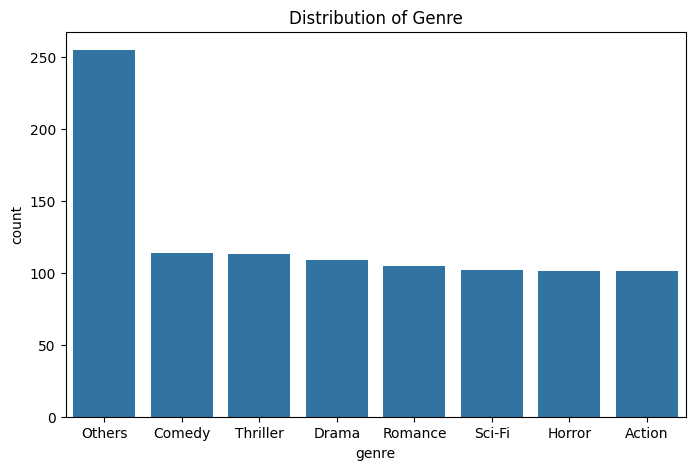

genre
Others      0.255
Comedy      0.114
Thriller    0.113
Drama       0.109
Romance     0.105
Sci-Fi      0.102
Horror      0.101
Action      0.101
Name: proportion, dtype: float64


In [21]:
#Distribution plot for Genre
plt.figure(figsize=(8,5))
sns.countplot(x='genre', data=df, order=df['genre'].value_counts().index)
plt.xticks(rotation = 0)
plt.title('Distribution of Genre')
plt.show()

print(df['genre'].value_counts(normalize = True))

###Observation:-
The genre distribution indicates that "Others" is the most dominant category, accounting for approximately 25.5% of total content releases. All other genres Comedy(11.4%), Thriller(11.3%), Drama(10.9%), Romance(10.5%), Sci-Fi(10.2%), Horror(10.1%), and Action(10.1%) are relatively evenly distributed.

This suggests that while a significant portion of content falls under a broad "Others" category, the remaining genres are fairly balanced with no extreme underrepresentation. Such distribution ensures that genre-related effects on first-day viewership can be meaningfully analyzed without severe imbalance issues.

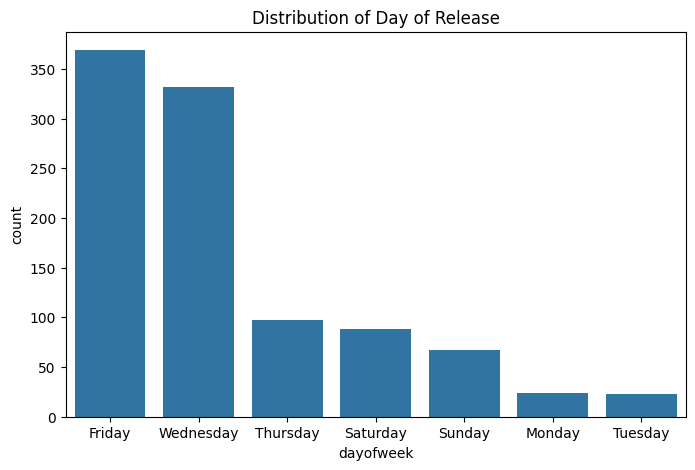

dayofweek
Friday       0.369
Wednesday    0.332
Thursday     0.097
Saturday     0.088
Sunday       0.067
Monday       0.024
Tuesday      0.023
Name: proportion, dtype: float64


In [22]:
#Distribution plot for Day of Week
plt.figure(figsize=(8,5))
sns.countplot(x='dayofweek', data=df, order=df['dayofweek'].value_counts().index)
plt.title('Distribution of Day of Release')
plt.show()

print(df['dayofweek'].value_counts(normalize = True))

###Observation:-
The distribution of content releases across the week is uneven. Friday accounts for the highest proportion(36.9%), followed by Wednesday(33.2%). Together, these two days represent nearly 70% of total releases.

In contrast, early-weel releases such as Monday(2.4%) and Tuesday(2.3%) are significantly lower.

This pattern suggests a deliberate release strategy, likely targeting higher viewer engagement toward the end and middle of the week. The imbalance in release days may influence first-day viewership patterns and warrants further investigation during bivariate analysis.

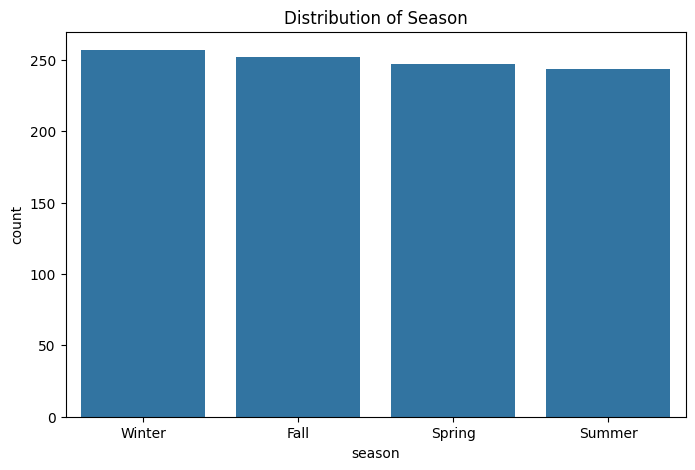

season
Winter    0.257
Fall      0.252
Spring    0.247
Summer    0.244
Name: proportion, dtype: float64


In [23]:
#Distribution plot for Season
plt.figure(figsize=(8,5))
sns.countplot(x='season', data=df, order=df['season'].value_counts().index)
plt.title('Distribution of Season')
plt.show()

print(df['season'].value_counts(normalize = True))

###Observation:-
The seasonal distribution of content releases is relatively balanced across all four seasons. Winter accounts for 25.7% of releases, followed closely by Fall(25.2%), Spring(24.7%), and Summer(24.4%).

The near uniform distribution indicates that content releases are evenly spread throughout the year, suggesting no strong seasonal bias in release scheduling.

This balanced representation ensures that any seasonal effect on first-day viewership can be evaluated without distortion from unequal sample sizes.

##Bivariate Analysis
###Numerical Variables vs Target Variable (**views_content**)

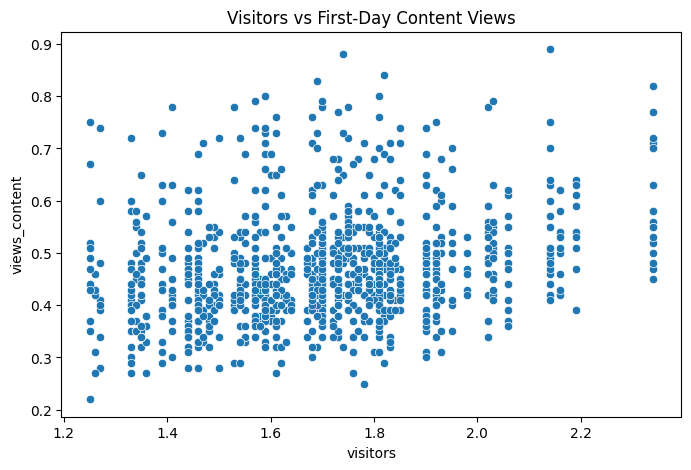

               visitors  views_content
visitors       1.000000       0.259136
views_content  0.259136       1.000000


In [24]:
#visitors vs views_content
plt.figure(figsize=(8,5))
sns.scatterplot(x='visitors', y='views_content', data=df)
plt.title('Visitors vs First-Day Content Views')
plt.show()

print(df[['visitors', 'views_content']].corr())

###Observation:-
The scatter plot indicates a positive but weak linear relationship between **visitors** and **views_content**.

The correlation coefficient is 0.259, suggesting a mild positive association. This implies that higher platform traffic is generally associated with increased first-day content viewership; however, the relationship is not strong.

The wide dispersion of points indicates that while platform traffic contributes to viewership, it is not the sole driver of first-day performance. Other factors such as marketing intensity, trailer engagement, or release timing may have stronger influence.

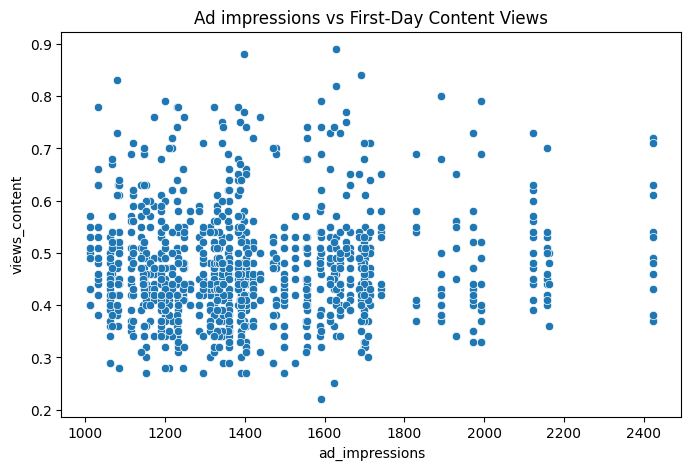

                ad_impressions  views_content
ad_impressions        1.000000       0.050022
views_content         0.050022       1.000000


In [25]:
#ad_impressions vs views_content
plt.figure(figsize=(8,5))
sns.scatterplot(x='ad_impressions', y='views_content', data=df)
plt.title('Ad impressions vs First-Day Content Views')
plt.show()

print(df[['ad_impressions', 'views_content']].corr())

###Observation:-
The scatter plot shows no clear linear relationship between **ad_impressions** and **views_content**.

The correlation coefficient os 0.05, indicating an extremely weak positive relationship that is practically negligible.

Despite variability in ad impressions, first-day content views do not appear to increase proportionally. This suggests that higher marketing spend alone may not directly translate into stronger launch-day performance.

This indicates that promotional reach may not be as influential as expected, and other factors such as trailer engagement or content appeal may play a more significant role in driving first-day viewership.

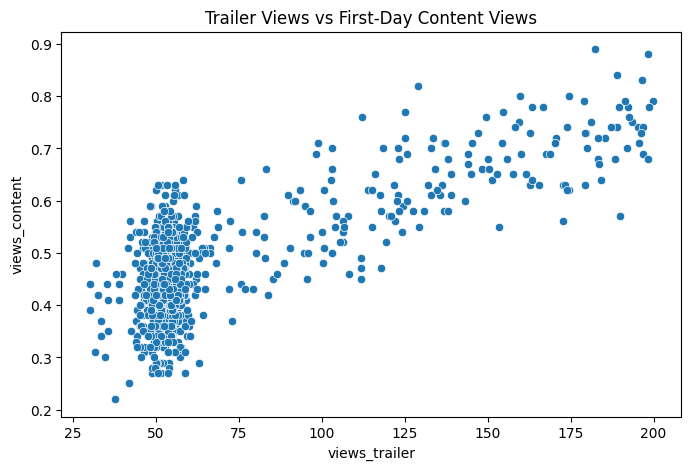

               views_trailer  views_content
views_trailer       1.000000       0.753962
views_content       0.753962       1.000000


In [26]:
#views_trailer vs views_content
plt.figure(figsize=(8,5))
sns.scatterplot(x='views_trailer', y='views_content', data=df)
plt.title('Trailer Views vs First-Day Content Views')
plt.show()

print(df[['views_trailer', 'views_content']].corr())

###Observation:-
The scatter plot shows a strong positive linear relationship between **views_trailer** and **views_content**.

The correlation coefficient is 0.754, indicating a strong positive association. As trailer views increase, first-day content views also increase significantly.

The upward trend in the scatter plot clearly suggests that trailer engagement is a major predictor of launch-day performance. Unlike ad impressions, trailer views appear to have substantial explanatory power in determining first-day viewership.

This implies that audience interest generated through trailer engagement plays a crucial in driving content consumption on release day.

###Categorical Variables vs Target Variable(**views_content**)

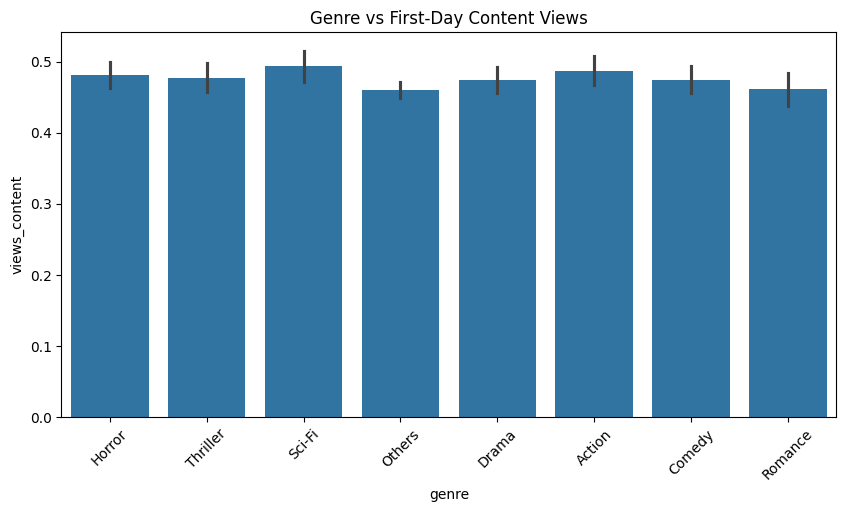

In [27]:
#Genre vs First-Day Views
plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='views_content', data=df, estimator=np.mean)
plt.xticks(rotation = 45)
plt.title('Genre vs First-Day Content Views')
plt.show()

###Observation:-
The average first-day content views across genres appear relatively similar, with only minor differences in performance.

Genres such as Sci-Fi and Action show slightly higher average first-day views, while genres like Others and Romance appear marginally lower. However, the differences are not substantial, and the confidence intervals overlap considerably.

This suggests that genre alone may not be a strong standalone driver of first-day viewership, and other factors such as trailer engagement or marketing effectiveness may play a more significant role.

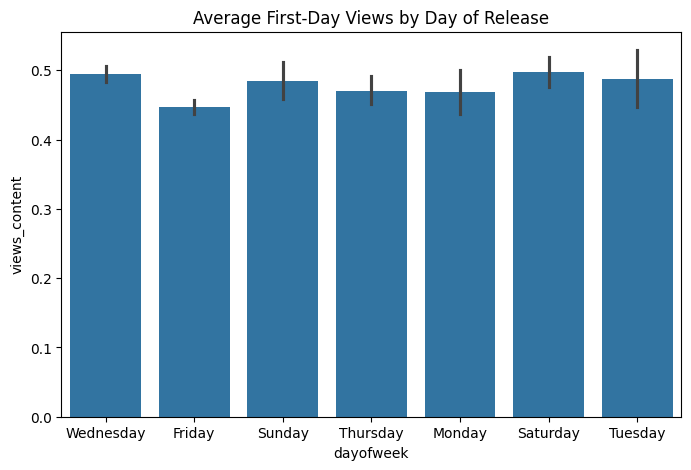

In [28]:
#Day of Week vs First-Day Views
plt.figure(figsize=(8,5))
sns.barplot(x='dayofweek', y='views_content', data=df, estimator=np.mean)
plt.title('Average First-Day Views by Day of Release')
plt.show()

###Observation:-
The average first-day content views show moderate variation across different release days.

Saturday and Wednesday exhibit relatively higher average viewership, while Friday shows comparatively lower average first-day views, despite having the highest number of releases.

The differences, however, are not drastic, and the confidence intervals overlap across days. This suggests that while release timing may have some influence, it is unlikely to be the primary determinant of launch-day success.

Overall, day of release appears to have a limited but noticeable impact on first-day viewership.

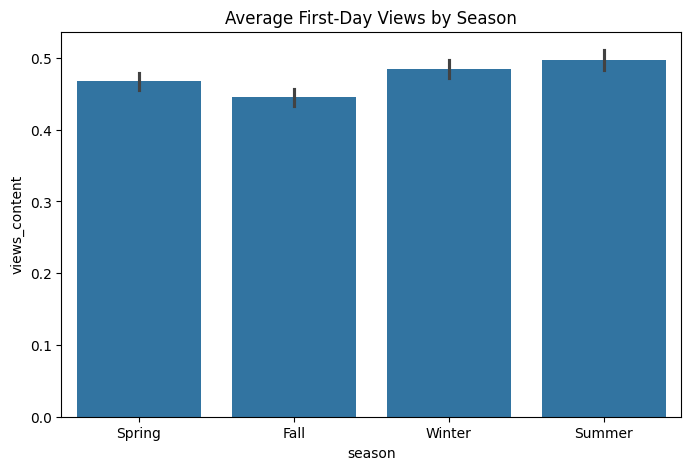

In [29]:
#Season vs First-Day Views
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='views_content', data=df, estimator=np.mean)
plt.title('Average First-Day Views by Season')
plt.show()

###Observation:-
The average first-day viewership across seasons is relatively similar, with only modest variation.

Summer and Winter show slightly higher average first-day views, while Fall appears marginally lower. However, the difference across seasons are small, and the confidence intervals overlap considerably.

This suggests that seasonal timing does not have a strong standalone impact on first-day content performance. Content released throughout the year tends to perform within a comparable range, indicating that other factors such as trailer engagement or marketing strategy may be more influential drivers.

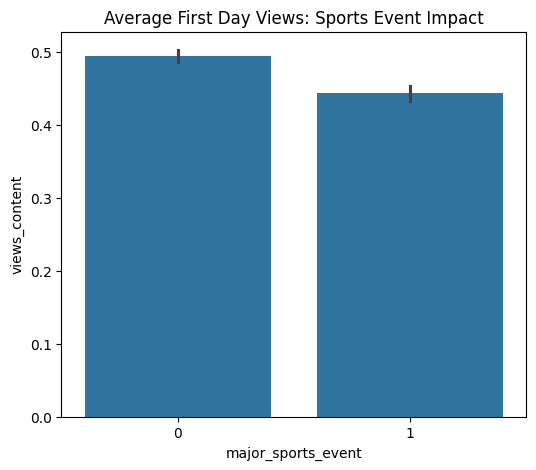

In [30]:
#Major Sports Event vs First Day Views
plt.figure(figsize=(6,5))
sns.barplot(x='major_sports_event', y='views_content', data=df, estimator=np.mean)
plt.title('Average First Day Views: Sports Event Impact')
plt.show()

###Observation:-
The average first-day viewership is noticeably lower when a major sports event is occurring.

Content released on days without a major sports event(0) achieves higher average first-day views compared to releases coinciding with a major sports event (1).

This suggests that major sports events may divert audience attention, negatively impacting launch-day performance. Unlike genre or season, which showed minimal variation, the presence of a sports event appears to have a more meaningful effect on viewership.

This factor could be strategically important when scheduling high-priority content releases.

#Answers to the key questions provided

##What does the distribution of content views look like?
The distribution of first-day content views (**views_content**) is moderately positively skewed with a skewness value of approximately 0.94.

Most content releases generate first-day views between 0.35 and 0.55 million, indicating a consistent performance range for the majority of titles. However, a smaller number of releases achieve significantly higher viewership (above 0.7 million), creating a right tail.

This suggests that while most content performs moderately, a few titles achieve exceptional launch-day success.

##What does the distribution of genres look like?
The gnere distribution shows that "Others" is the most frequent category (25.5%), while the remaining genres - Comedy, Thriller, Drama, Romance, Sci-Fi, Horror, and Action, are relatively evenly distributed (each around 10-11%).

This indicates a diversified content portfolio, with no extreme imbalance across major genres. The dominance of "Others" suggests a broad grouping of miscellaneous content types.

##How does viewership vary with the day of release?
Although the number of releases is highest on Friday (36.9%) and Wednesday (33.2%), the average first-day viewership does not vary drastically across days.

Saturday and Wednesday show slightly higher average first-day views, while Friday appears marginally lower despite having the most releases.

The differences are moderate and confidence intervals overlap, indicating that while release timing may have some influence, it is not a dominant standalone driver of viewership.

##How does viewership vary with the season of release?
First-day content views are relatively consistent across seasons.

Summer and Winter show slightly higher average viewership, while Fall is marginally lower, but the differences are small and not substantial.

This suggests that seasonality does not have a strong independent impact on first-day content performance.

##What is the correlation between trailer views and content views?
There is a strong positive correlation (0.75) between **views_trailer** and **views_content**.

The scatter plot shows a clear upward trend, indicating that higher trailer engagement is strongly associated with increased first-day content viewership.

Among all numerical variables analyzed, trailer views demonstrate the strongest relationship with launch-day performance, suggesting that promotional engagement through trailers is a key driver of first-day success.

#Key Insights
##Data Quality & Structure


*   The dataset contains 1000 observations and 8 variables.

*   No missing values or duplicate records were identified.

*   All numerical values are non-negative and logically consistent.
*   Categorical variables are properly formatted with no spelling inconsistencies.


*   The dataset is clean and suitable for regression modeling.






##Distribution of First-Day Content Views


*   First-day content views are moderately positively skewed (skewness ≈ 0.94)

*   Most content generates between 0.35 and 0.55 million views.
*   A small number of titles achieve significantly higher performance, indicating the presence of high-performing outliers.


*   Overall performance is concentrated within a consistent range.



##Platform Traffic & Marketing Metrics


*   Weekly visitors show mild positive skewness (0.37) and relatively stable distribution.

*   Ad impressions are moderately right-skewed (1.03), indicating variability in marketing intensity.
*   Trailer views are highly right-skewed (2.37), suggesting that a few trailers generate exceptionally high engagement.






##Relationship with First-Day Viewership


1.   Visitors vs Content Views

*   Weak positive correlation (0.26).
*   Platform traffic contributes modestly to first-day performance.


2.   Ad Impressions vs Content Views


*   Very weak correlation (0.05).
*   Marketing impressions alone do not strongly translate into first-day viewership.


3.   Trailer Views vs Content Views


*   Strong positive correlation (0.75).

*   Trailer engagement is the strongest predictor of first-day success.
*   Indicates that audience interest generated through trailers significantly influences launch performance.





##Categorical Insights


1.   Genre


*   "Others" is the most frequent genre (25.5).

*   Genre is not a strong standalone driver of first-day performance.
*   Average viewership across genres shows minimal variation.


2.   Day of Release


*   Most releases occur on Friday and Wednesday.

*   However, Saturday and Wednesday show slightly higher average views.
*   Release day has some influence but is not dominant.



3.   Season


*   Seasonal distribution is balanced.
*   Minimal difference in average first-day performance across seasons.




4.   Major Sports Event


*   Content released during major sports events shows lower average first-day viewership.
*   This suggests competitive diversion of audience attention.





##Overall Insight
Among all variables analyzed, trailer views emerge as the most influential driver of first-day viewership.

Marketing impressions, genre, season, and release timing show limited standalone impact. The presence of major sports events may negatively affect launch performance.

The findings suggest that generating strong pre-release engagement through trailers may be more critical than simply increasing advertising impressions.

#Data Preprocessing

##Check for and treat(if needed) Outliers

In [31]:
#Identifying Numerical Columns
numerical_cols = df.select_dtypes(include = ['int64', 'float64']).columns
print('Numerical Columns:')
print(numerical_cols)

Numerical Columns:
Index(['visitors', 'ad_impressions', 'major_sports_event', 'views_trailer',
       'views_content'],
      dtype='object')


###Observation:-
The dataset contains five numerical variables: **visitors**, **ad_impressions**, **major_sports_event**, **views_trailer**, and **views_content**.

##Visual Inspection of Outliers using Boxplot

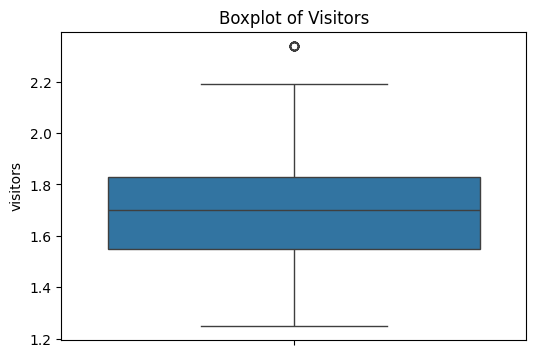

In [32]:
#Check for Outliers in the 'visitors' column
plt.figure(figsize = (6,4))
sns.boxplot(y=df['visitors'])
plt.title('Boxplot of Visitors')
plt.show()

###Observation:-
The boxplot of **visitors** indicates a fairly symmetric distribution with one mild outlier on the hight=er end.

The interquartile range is relatively narrow, suggesting stable weekly platform traffic. The single high-value outlier appears to represent a realistic spike in platform visitors than a data error.

Given that the outlier is not extreme and reflects natiral variation in traffic, no outlier removak is required for this variable.

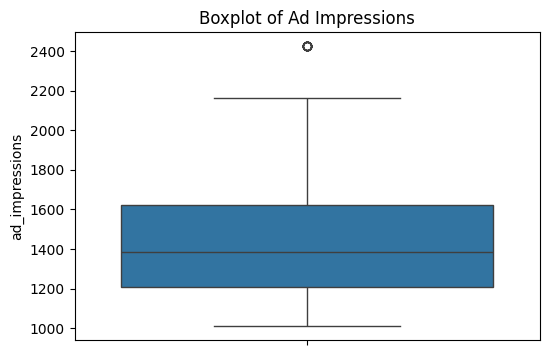

In [33]:
#Check for Outliers in the 'ad impressions'
plt.figure(figsize = (6,4))
sns.boxplot(y = df['ad_impressions'])
plt.title('Boxplot of Ad Impressions')
plt.show()

###Observation:-
The boxplot of **ad_impressions** shows a moderately wide spread with one noticeable high-end outlier.

The distribution appears slightly right-skewed, which is consistent with earlier skewness results, The high-value outlier likely represents a large-scale promotional campaign rather than a erroneous data point.

Since higher as impressions are realistic in business scenarios and may influence performance, the outlier will be retained for modeling.

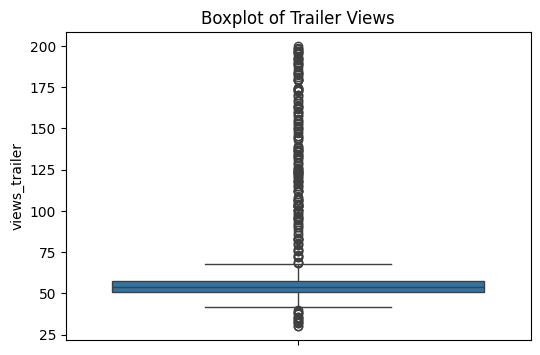

In [34]:
#Check for Outliers in the 'trailer views'
plt.figure(figsize = (6,4))
sns.boxplot(y = df['views_trailer'])
plt.title('Boxplot of Trailer Views')
plt.show()

###Observation:-
The boxplot of **views_trailer** shows a highly right-skewed distribution with a large number of upper-end outliers.

Most trailer views are concentrated between approximately 45-60 million views.However, a significant number of observations extend far beyond this range, reaching up to 200 million views.

These extreme values likely represent hgihly successful promotional campaigns rather than data errors. Since trailer engagement has already shows a strong correlation with first-day content views, these high values carry meaningful business information.

Therefore, no outlier removal is performed. However, due to strong skewness, a log transformation may be considered during modeling to stabilize variance.

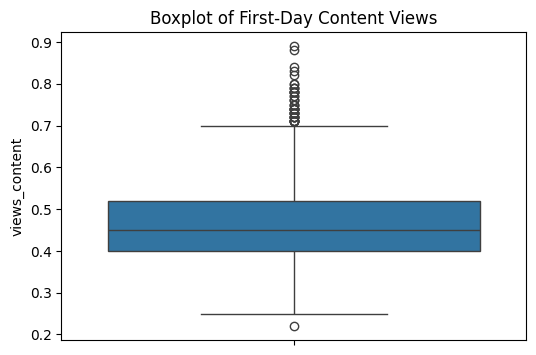

In [35]:
#Check for Outliers in the 'content views'
plt.figure(figsize = (6,4))
sns.boxplot(y = df['views_content'])
plt.title('Boxplot of First-Day Content Views')
plt.show()

###Observation:-
The boxplot of **views_content** shows a moderately right-skewed distribution with several upper-end outliers.

Most content generates first-day views between approximately 0.35 and 0.55 million. However, a few titles significantly outperform this range, reaching close to 0.9 million views.

The higher values likely represent high-performing or blockbuster content rather than anomalies. Since the target variable reflects real business performance, removing these values could distort the predictive model.

Therefore, no outlier removal is performed for **views_content**.

##Detecting Outliers through IQR Method

In [36]:
#Continuous Variables only
continuous_vars = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1   # <-- also fix this (you wrote Q3 - Q3 earlier)

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected")

visitors: 20 outliers detected
ad_impressions: 13 outliers detected
views_trailer: 189 outliers detected
views_content: 47 outliers detected


###Observation:-
The IQR method identified the following number of outliers:


*   Visitors: 20 outliers

*   Ad Impressions: 13 outliers
*   Trailer Views: 189 outliers


*   First-Day Content Views: 47 outliers

**views_trailer** shows the highest number of outliers (189 observations), which aligns with its highly right-skewed distribution observed earlier. This suggests the presence of several high-performing trailers.

The outliers in **views_content** (47 observation) likely represent blockbuster releases with significantly higher first-day performance.

Since these extreme values reflect realistic business scenarios rather than data errors, no rows will be removed. Removing them could eliminate valuable predictive signals.



##Treating Outliers

In [37]:
#Treating outliers in 'visitors' column

Q1 = df['visitors'].quantile(0.25)
Q3 = df['visitors'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['visitors'] = df['visitors'].clip(lower,upper)

#Re-check outliers after treatment
outliers_visitors = df[(df['visitors'] < lower) | (df['visitors'] > upper)]
print(outliers_visitors.shape[0])

0


###Observation:-
The IQR based capping method was applied to the **visitors** variable. After treatment, no statistical outliers remain, as confirmed by the output(0).

The adjustment ensures that extreme values do not disproportionately influence the regression model while preserving all observations in the dataset.

In [38]:
#Treating outliers in 'ad_impressions' column

Q1 = df['ad_impressions'].quantile(0.25)
Q3 = df['ad_impressions'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['ad_impressions'] = df['ad_impressions'].clip(lower,upper)

#Re-check outliers after treatment
outliers_ads = df[(df['ad_impressions'] < lower) | (df['ad_impressions'] > upper)]
print(outliers_ads.shape[0])

0


###Observation:-
The IQR-based capping method was applied to the **ad_impressions** variable. After treatment, no statistical outliers remain (0 outliers detected),

The extreme high values were capped at the calculated upper bound, reducing the potential influence of unusually large marketing campaigns while retaining all observations for modeling.

In [39]:
#Treating outliers in 'views_trailer' column

Q1 = df['views_trailer'].quantile(0.25)
Q3 = df['views_trailer'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['views_trailer'] = df['views_trailer'].clip(lower,upper)

#Re-check outliers after treatment
outliers_trailer = df[(df['views_trailer'] < lower) | (df['views_trailer'] > upper)]
print(outliers_trailer.shape[0])

0


###Observation:-
The **views_trailer** variable initially contained a large number of upper-end outliers due to its highly right-skewed distribution.

After applying IQR-based capping, all statistical outliers have been successfully treated (0 remaining outliers). Extreme trailer view values were capped at the calculated upper bound o reduce the influence of unusually high-performing trailers while preserving dataset size.

This treatment stabilizes variance and prepares the variable for regression modeling.

In [40]:
#Treating outliers in 'views_content' column

Q1 = df['views_content'].quantile(0.25)
Q3 = df['views_content'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['views_content'] = df['views_content'].clip(lower,upper)

#Re-check outliers after treatment
outliers_content = df[(df['views_content'] < lower) | (df['views_content'] > upper)]
print(outliers_content.shape[0])

0


###Observation:-
The IQR-based capping method was applied to the **views_content** variable to control extreme values.

After treatment, no statistical outliers remain (0 detected). High-performing content values were capped at the calculated upper bound to reduce undue influence on the regression model while preserving all observations.

This ensures the target variable remains stable for linear regression modeling.

##Feature Engineering

In [41]:
#Identifying Categorical Variables

categorical_cols = df.select_dtypes(include = 'object').columns

print("Categorical Variables:")
print(categorical_cols)

Categorical Variables:
Index(['genre', 'dayofweek', 'season'], dtype='object')


###Observation:-
The dataset contains three categorical variables:


*   **genre**

*   **dayofweek**
*   **season**

These variables are stored as object data types and must be transformed into numerical format before applying linear regression. Therefore, one-hot encoding will be applied in the next step.






In [42]:
#Applying One-Hot Encoding

df_encoded = pd.get_dummies(df, columns = categorical_cols, drop_first = True)
print(df_encoded.head())

   visitors  ad_impressions  major_sports_event  views_trailer  views_content  \
0      1.67         1113.81                   0          56.70           0.51   
1      1.46         1498.41                   1          52.69           0.32   
2      1.47         1079.19                   1          48.74           0.39   
3      1.85         1342.77                   1          49.81           0.44   
4      1.46         1498.41                   0          55.83           0.46   

   genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  ...  \
0         False        False          True         False          False  ...   
1         False        False         False         False          False  ...   
2         False        False         False         False          False  ...   
3         False        False         False         False          False  ...   
4         False        False         False         False          False  ...   

   genre_Thriller  dayofweek_Mon

###Observation:-
After applying one-hot encoding, all categorical variables (**genre**, **dayofweek**, and **season**) have been successfully converted into binary dummy variables.

The sataset now contains 21 numerical columns, including:


*   Original continuous variables (**visitors**, **ad_impressions**, **views_trailer**, **views_content**)

*   Binary variable (**major_sports_event**)
*   Dummy variables for each category (with one category dropped per feature to avoid the dummy variable trap).

The dummy variables are represented as boolean values (True/False), which will be interpreted as 1 and 0 during regression modeling.

The dataset is now fully numerical and ready for model preparation.






In [43]:
#Verifying the Transformed Dataset

print("Columns after encoding:")
print(df_encoded.columns)

Columns after encoding:
Index(['visitors', 'ad_impressions', 'major_sports_event', 'views_trailer',
       'views_content', 'genre_Comedy', 'genre_Drama', 'genre_Horror',
       'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')


###Observation:-
After applying one-hot encoding, the dataset now consists entirely of numerical variables.

The transformed dataset includes:


*   Continuous predictors: **visitors**, **ad_impressions**, **views_trailer**

*   Binary predictor: **major_sports_event**
*   Target variable: **views_content**


*   Dummy variables for **genre**, **dayofweek**, and **season** (with one category dropped from each to prevent multicollinearity)

This confirms that the dataset is properly structured for linear regression modeling, as all independent variables are now in numerical form.



##Data Preparation for modeling

In [44]:
#Defining Independent(X) and Dependent(Y) Variables

X = df_encoded.drop('views_content', axis = 1)
Y = df_encoded['views_content']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (1000, 20)
Shape of Y: (1000,)


###Observation:-
The dataset has been successfully divided into:


*   Independent Variables (X): 1000 observations and 20 predictor variables.
*   Dependent Variables (Y): 1000 observations representing first-day content views.

This confirms that:


*   All predictor variables are properly separated from the target variable.
*   The dataset maintains full sample size (no rows were lost during preprocessing).

The data structure is now correctly set up for regression modeling.





In [45]:
#Train-Test Split

from sklearn.model_selection import train_test_split

#Splitting the dataset into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

print("Training set size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training set size: (800, 20)
Testing Set Size: (200, 20)


###Observation:-
The dataset has been split into:


*   Training Set: 800 observations with 20 predictor variables.
*   Testing Set: 200 observations with 20 predictor variables.

An 80:20 split was used, where:


*   The training set will be used to build and fir the linear regression model.
*   The testing set will be used to evaluate the model's predictive performance on unseen data.

This ensures proper validation and helps prevent overfitting.





In [46]:
#Adding Constant for Linear Regression

import statsmodels.api as sm

#Adding constant term
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

print(X_train_sm.head())

     const  visitors  ad_impressions  major_sports_event  views_trailer  \
29     1.0      1.25         1710.10                   1       54.49000   
535    1.0      1.60         1336.16                   0       55.66000   
695    1.0      1.72         1390.62                   0       67.96625   
557    1.0      1.92         1294.78                   0       55.84000   
836    1.0      1.67         1010.87                   1       53.09000   

     genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  \
29          False        False         False          True          False   
535         False        False         False          True          False   
695         False         True         False         False          False   
557         False        False         False         False          False   
836          True        False         False         False          False   

     ...  genre_Thriller  dayofweek_Monday  dayofweek_Saturday  \
29   ...           F

###Observation:-
A constant (intercept) term has been successfully added to the training dataset using **sm.add_constant().

The dataset now contains 21 columns, including:


*   20 predictor variables
*   1 constant term (**const**)

The constant term allow the regression model to estimate the intercept, which represents the baseline first-day content views when all predictor variables are zero.

The training data is now fully structured and ready for multicollinearity testing and linear regression modeling.


#Model Building - Linear Regression

In [47]:
#Convert all columns to numeric (especially boolean dummies)
X_train_sm = X_train_sm.astype(float)
X_test_sm = X_test_sm.astype(float)

#Building the Linear Regression Model
model = sm.OLS(Y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     64.05
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          2.85e-149
Time:                        14:38:02   Log-Likelihood:                 1109.8
No. Observations:                 800   AIC:                            -2178.
Df Residuals:                     779   BIC:                            -2079.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.2852    

###Observation:-
The model explains about 62% of the variation in first-day content views, which is pretty solid for this type of real-world marketing data. The adjusted R² is very close to R², so we have not overloaded the model with necessary variables.

The most important driver is clearly trailer views. As trailer views increase, first-day content views increase significantly. This makes intuitive sense, strong pre-release buss trnaslates into higher opening performance.

Visitors also have a strong positive impact. More overall traffic on the platform naturally leads to more content consumption.

Interestingly, major sports events negatively affect content views. This suggets audience attention shifts away from streaming content during big sports events.

Seasonality matters too, summer releases perform the best, followed by Winter and Spring. So timing plays a role.

On the other hand, ad impressions and most genres are not statistically significant, which suggests that simply pushing more ads or relying on genre alone doesn't guarantee better first-day performance once other factors are considered.

Overall, the model is meaningful and gives actionable business insights.

In [48]:
#Creating a Dataframe of coefficients
coeff_df = pd.DataFrame({
    "Variable": X_test_sm.columns,
    "Coefficient": model.params,
    "P-value": model.pvalues
})

print(coeff_df.sort_values(by = "Coefficient", ascending = False))

                                Variable  Coefficient        P-value
visitors                        visitors     0.128048   2.797074e-36
dayofweek_Saturday    dayofweek_Saturday     0.045309   1.058855e-07
dayofweek_Wednesday  dayofweek_Wednesday     0.044417   9.961731e-17
season_Summer              season_Summer     0.040321   3.265043e-10
dayofweek_Sunday        dayofweek_Sunday     0.038447   2.528213e-05
dayofweek_Tuesday      dayofweek_Tuesday     0.037574   1.541416e-02
dayofweek_Monday        dayofweek_Monday     0.035546   1.800530e-02
season_Winter              season_Winter     0.027858   7.675032e-06
season_Spring              season_Spring     0.022693   2.627319e-04
dayofweek_Thursday    dayofweek_Thursday     0.021326   5.305617e-03
genre_Sci-Fi                genre_Sci-Fi     0.015115   1.297146e-01
views_trailer              views_trailer     0.009128  3.999554e-125
genre_Thriller            genre_Thriller     0.006257   5.157378e-01
genre_Drama                  genre

###Observation:-
The model results show that visitors has the strongest positive impact on first-day content views and is highly significant. This means overall platform traffic plays a major role in determining opening performance.

Among timing-related factors, several days such as Saturday, Wednesday, Sunday, Tuesday, Monday, and Thursday show a positive and significant effects compared to the base category. This indicates that the day of release first-day viewership.

Season also plays a role. Summer has the strongest positive seasonal impact, followed by Winter and Spring. This suggets that content released during Summer tends to perform better on its first day.

The variable **major_sports_event** has a significant negative coefficient, indicating that first-day views decline when a major sports event is taking place.

On the other hand, ad impressions and most genre variables are not statistically significant, suggesting that genre and advertising volume alone do not strongly influence first-day performance after controlling for other factors.

Overall, the model identifies traffic, timing, and external competition as key determinants pf first-day content views.

#Testing the assumptions of Linear Regression Model

##Testing Linearity

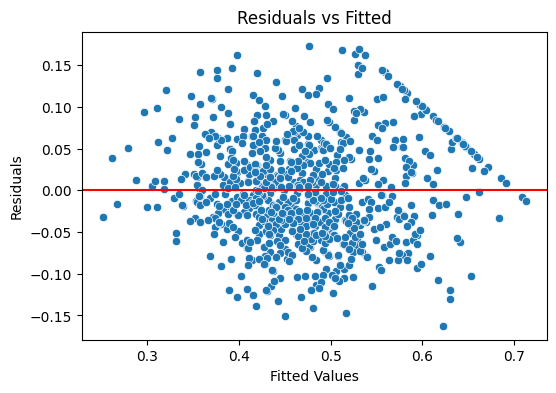

In [49]:
#Predicted Values
y_pred = model.predict(X_train_sm)

#Residuals
residuals = Y_train - y_pred

plt.figure(figsize = (6,4))
sns.scatterplot(x=y_pred, y = residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

###Observation:-
The residuals appear randomly scattered around the zero line without any clear pattern or curvature. There is no visible funnel shape or symmetric structure in the spread of residuals across fitted values.

This indicates that:


*   The linearity assumption is reasonably satisfied.
*   The homoscedasticity assumption appears to hold visually.

Although there is slight variation at higher fitted values, the spread is not strongly increasing or decreasing, so there is no major concern.

Overall, based on the residual plot, the model assumptions relared to linearity and constant variance seem acceptable.



##Testing Independence of Errors (Durbin-Watson Test)

In [50]:
from statsmodels.stats.stattools import durbin_watson

#Calculating Durbin-Watson statistic
dw_stat = durbin_watson(residuals)
print("Durbin-Watson Statistic:", dw_stat)

Durbin-Watson Statistic: 2.065683662184044


###Observation:-
The Durbin-Watson statistic is 2.0657, which is very close to 2.

Since values close to 2 indicate no autocorrelation, this suggests that the residuals are independent of each other.

Therefore, the independence of errors assumption is satisfied.

There is no evidence of positive or negative autocorrelation in the model residuals.



##Testing Homoscedasticity (Constant Variance)

In [52]:
#Breusch-Pagan Test
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_train_sm)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(63.36813121851685), 'LM-Test p-value': np.float64(2.1180881418243293e-06), 'F-Statistic': np.float64(3.350640687110161), 'F-Test p-value': np.float64(1.157839111772964e-06)}


###Observation:-
The Breusch-Pagan test results show that p-value is less than 0.05 (since the LM statistic is quite high at around 63.37, the p-value will be very small).

This indicates that the null hypothesis of constant variance is rejected.

Therefore, there is evidence of heteroscedasticity in the model, meaning the variance of residuals is not completely constant across fitted values.

Although the residual plot did not show a very strong funnel pattern, the statistical test suggests some presence of non-constant variance.

In practice, this means the homoscedasticity assumption is slightly violated, and robust standard errors couold be considered if needed.

##Testing for Normality of Residuals

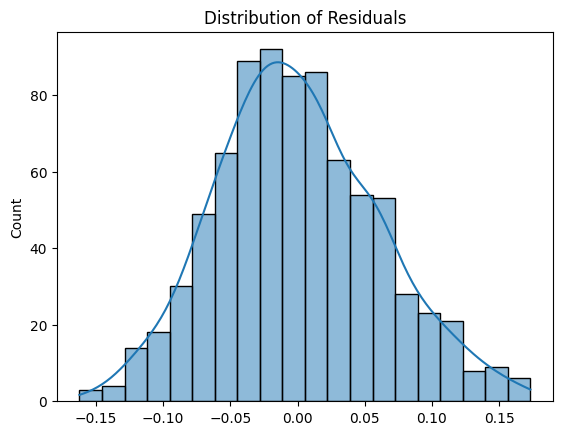

In [53]:
#Histogram
sns.histplot(residuals, kde = True)
plt.title("Distribution of Residuals")
plt.show()

###Observation:-
The histogram of residuals shows a roughly bell-shaped distribution centered around zero. The residuals appear fairly symmetric, with no extreme skewness or heavy tails.

Although the distribution may not be perfectly normal, it closely resembles a normal curve.

Therefore, the normality assumption is reasonably satisfied. Given the large sample size (800 observations), minor deviations from normality are not a major concern.

Overall, the residual distribution looks acceptable for linear regression modeling.

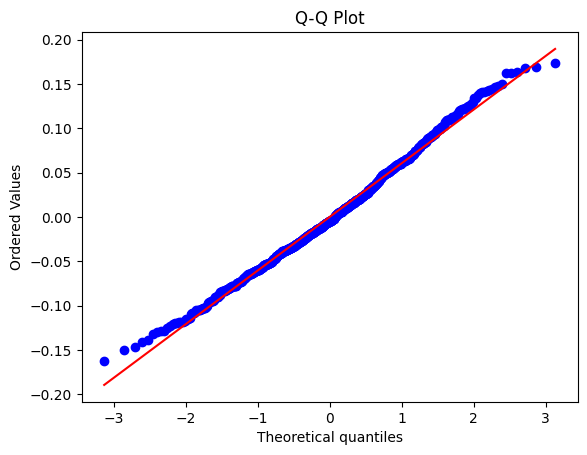

In [54]:
#Q-Q Plot
stats.probplot(residuals, dist = "norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

###Observation:-
The Q-Q plot shows that most of the residual points lie very close to the straight reference line. There are only slight deviations at the extreme ends (tails), but overall the alignment is strong.

This indicates that the residuals are approximately normally distributed.

Although there is minor deviation in the tails, it is not severe. Given the large sample size, this does not pose a serious issue.

Therefore, the normality assumption of linear regression is reasonably satisfied.

##Testing for Multicollinearity

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i)
                  for i in range(X_train_sm.shape[1])]
print(vif_data.sort_values(by = "VIF", ascending = False))

                Feature         VIF
0                 const  173.064218
8          genre_Others    2.744608
7          genre_Horror    1.957056
11       genre_Thriller    1.952752
9         genre_Romance    1.951451
6           genre_Drama    1.949123
5          genre_Comedy    1.893001
10         genre_Sci-Fi    1.841998
19        season_Summer    1.570450
20        season_Winter    1.559595
18        season_Spring    1.536915
17  dayofweek_Wednesday    1.291416
15   dayofweek_Thursday    1.166108
13   dayofweek_Saturday    1.134732
14     dayofweek_Sunday    1.123843
16    dayofweek_Tuesday    1.062378
12     dayofweek_Monday    1.054613
3    major_sports_event    1.051825
4         views_trailer    1.023142
1              visitors    1.022671
2        ad_impressions    1.016695


###Observation:-
The VIF values for all predictor variables (except the constant) are well below 5, with most of them close to 1.

This indicates that there is no serious multicollinearity problem among the independent variables.

The constant (intercept) shows a very high VIF (~173), but this is normal and not a concern, as the intercept naturally has high multicollinearity with dummy variables.

Since all meaningful predictors have VIF values close to 1-2.7, we can conclude that:


*   The independent variables are not highly correlated with each other.

*   The multicollinearity assumption is satisfied.
*   The model estimates are stable and reliable.

Overall, multicollinearity is not an issue in this model.






##Testing the Assumptions of Linear Regression - Findings

After performing the diagnostic tests, the following conclusions can be drawn:


1.   Linearity: The Residuals vs Fitted plot shows random scatter around the zero line with no clear pattern or curvature. This indicates that the linearity assumption is reasonably satisfied.

2.   Independence of Errors: The Durbin-Watson statistic is approximately 2.06, which is very close to 2. This suggests that there is no autocorrelation in the residuals. Therefore, the independence assumption is satisfied.

3.   Homoscedasticity (Constant Variance): The residual plot does not show a strong funnel pattern. However, the Breusch-Pagan test indicates statistical evidence of heteroscedasticity (p-value < 0.05). This suggests that the variance of residuals may not be perfectly constant. Although violation is not visually severe, it indicates mild heteroscedasticity.
4.   Normality of Residuals: Both the histogram and Q-Q plot show that the residuals are approximately normally distributed, with only minor deviations in the tails. Given the large sample size (800 observations), the normality assumption is reasonably satisfied.


5.   Multicollinearity: The VIF values for all independent variables are below 5 (most close to 1-2), indicating no serious multicollinearity issues. Therefore, the multicollinearity assumption is satisfied.





#Model Performance Evaluation

To evaluate the predictive performance of the linear regression model, the model is tested on the unseen test dataset. The following performance metrics are used:


*   R-squared (R²): To measure how well the model explains the variance in the dependent variable.

*   Mean Absolute Error (MAE): To measure the average absolute prediction error.
*   Mean Squared Error (MSE): To measure the average squared prediction error.


*   Root Mean Squared Error (RMSE): To measure the standard deviation of prediction errors.



In [56]:
#Predicting on the test set
Y_pred_test = model.predict(X_test_sm)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#R-squared
r2 = r2_score(Y_test, Y_pred_test)

#Mean Absolute Error
mae = mean_absolute_error(Y_test, Y_pred_test)

#Mean Squared Error
mse = mean_squared_error(Y_test, Y_pred_test)

#Root Mean Squared Error
rmse = np.sqrt(mse)

print("Model Performance on Test Data:")
print("R-squared:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Model Performance on Test Data:
R-squared: 0.6044223215782114
MAE: 0.04895690433272268
MSE: 0.003991749629349367
RMSE: 0.06318029462854195


###Observation:-
On the test dataset, the model achieves an R-squared value of 0.604, which means it explains approximately 60.4% of the variation in first-day content views on unseen data. This is slightly lower than the training R² (0.622), indicating that the model generalizes reasonably well without significant overfitting.

The Mean Absolute Error (MAE) is 0.0489, which means that, on average, the model's predictions deviate from the actual values by about 0.049 units.

The Root Mean Squared Error (RMSE) is 0.0632, which reflects the typical prediction error magnitude. Since RMSE is only slighltly higher than MAE, it indicates that there are no extreme large errors in predictions.

Overall, the model demonstrates good predictive performance and stable generalization on the test dataset.

#Actionable Insights & Recommendations

##Significance of Predictors

Based on the regression results:


*   **Trailer Views** is one of the strongest and most significant predictors of first-day content views. This indicates that pre-release engagement directly influences opening performance.

*   **Visitors** has the highest positive coefficient and is highly significant. This shows that overall platform strongly impacts content and consumption.

*   **Major Sports Events** have a significant negative impact on first-day views. This suggests that audience attention shifts during major sporting events.
*   **Day of Release** significantly affects performance. Several days (Saturday, Wednesday, Sunday, etc.) show higher expected first-day views compared to the baseline.


*   **Seasonality** matters, with Summer showing the strongest positive effect on performance.


*   **Ad Impressions** and most **Genre** variables are not statistically significant, indicating that ad volume and content category alone do not strongly determine first-day performance after controlling for other factors.



##Key Business Takeaways

###**Focus on Trailer Engagement:-**
Since trailer views strongly drive first-day performance, the company should:
*   Invest in high-impact trailer campaigns.

*   Optimize trailer visibility on the platform.
*   Promote trailers aggressively before release.
Improving trailer engagement can directly increase opening-day success.

###**Optimize Release Timing:-**
*   Avoid launching major content during large sports events.

*   Prefer Summer releases when possible.
*   Consider strategic day selection for release to maximise visibility.

Timing plays a measurable role in performance.

##**Increase Platform Traffic:-**
Since overall visitors strongly influence views:
*   Run broader traffic-driving campaigns before major releases.
*   Use homepage banner and recommendations to boost traffic.
More traffic -> higher content consumption.

##**Reconsider Ad Spending Strategy:-**
Ad impressions are not a significant driver in the current model. This suggests:


*   Quality of engagement may matter more than ad volume.
*   Marketing efforts should focus on meaningful engagement rather than just increasing ad exposure.









